<a href="https://colab.research.google.com/github/VictorPortolani/am-turma5/blob/main/NaibeBayes_AtividadeCensus_VP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algoritmo de Naive Bayes[census]

## Carregamento de Dados Pickle

In [14]:
from sklearn.naive_bayes import GaussianNB

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import pickle
with open('/content/drive/MyDrive/am-t5/census.pkl', 'rb') as f:
  X_census_train, y_census_train, X_census_test, y_census_test = pickle.load(f)

In [17]:
X_census_train.shape, y_census_train.shape

((27676, 114), (27676,))

In [18]:
X_census_test.shape, y_census_test.shape

((4885, 114), (4885,))

## Montagem do Neurônio Especialista

In [19]:
neuronio_nb = GaussianNB()
neuronio_nb.fit(X_census_train, y_census_train)

GaussianNB()

Cenário Sintético

In [20]:
sintetico_census = neuronio_nb.predict(X_census_test)

In [21]:
sintetico_census

array([' >50K', ' >50K', ' >50K', ..., ' >50K', ' >50K', ' >50K'],
      dtype='<U6')

In [22]:
y_census_test

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

## Teste de Acurácia

In [23]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [24]:
accuracy_score(y_census_test, sintetico_census)

0.42292732855680654

0.42292732855680654

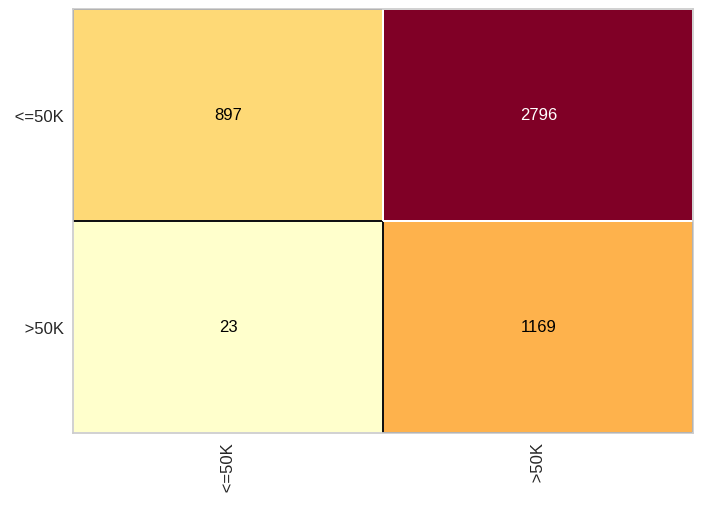

In [25]:
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(neuronio_nb)
cm.fit(X_census_train, y_census_train)
cm.score(X_census_test, y_census_test)

In [26]:
print(classification_report(y_census_test, sintetico_census))

              precision    recall  f1-score   support

       <=50K       0.97      0.24      0.39      3693
        >50K       0.29      0.98      0.45      1192

    accuracy                           0.42      4885
   macro avg       0.63      0.61      0.42      4885
weighted avg       0.81      0.42      0.40      4885



**Conclusão:** O algortimo de Naive Bayes teve uma acurácia de 42%, mas ele praticamente "chutou" que a maioria das pessoas ganha mais de 50 mil, o que gerou um recall alto (98%) para essa classe, mas despencou a precisão para 29%. Em contra partida ele ignorou a maior de quem realmente ganha menos que 50 mil (com reccal de apenas 24%), ou seja, conclui-se que o algoritmo ficou altamente enviesado e não conseguiu aprender padrões reais.